<a href="https://colab.research.google.com/github/Sank3t-Pand3y/Building_Advanced_Transformer_Using_KERAS./blob/main/Implementing_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Steps

#### Step 1: Preprocess data

Prepare the MNIST data set for training by normalizing the pixel values and reshaping the images to have a single color channel. Normalization helps in faster convergence during training, and reshaping is required because the input layer of your diffusion model expects a three-dimensional tensor.

**1. Load and preprocess the MNIST data set:**

- Use Keras to load the MNIST data set.
- Normalize the image pixel values to the range [0, 1].

**2. Reshape the Data:**
- Expand the dimensions of the images to match the input shape required by the model (28x28x1).


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

### Load the dataset
(x_train, _) , (x_test, _) = mnist.load_data()

## Normalize the pixel values
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

## Expand the dimensions to match the input shape (28,28,1)
## We expand from (28,28) to (28,28,1) because we know Convolutional Neural Network works on GrayScale or RGB image
x_train = np.expand_dims(x_train, axis = -1)
x_test = np.expand_dims(x_test, axis = -1)

## Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0 ,size= x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

## Clip the values to be within the range [0 ,1 ]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0. , 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Step 2: Build the diffusion model

Build a simple diffusion model with an encoder that compresses the input image into a latent representation and a decoder that reconstructs the image from this representation. The model is compiled with the Adam optimizer and binary cross-entropy loss.

**1. Define the encoder:**
- Create an input layer with the shape (28, 28, 1).
- Add two Conv2D layers with increasing filter sizes and ReLU activation.

**2. Define the bottleneck:**
- Add a flattened layer followed by a dense layer with ReLU activation.

**3. Define the decoder:**
- Add a Dense layer to expand the bottleneck representation.
- Reshape the output to match the original image dimensions.
- Add two Conv2DTranspose layers with decreasing filter sizes and ReLU activation.
  
**4. Compile the model:**
- Use the Adam optimizer and binary cross-entropy loss.


In [11]:
## Define the diffusion model architecture with reduced complexity

## 1. Input Layer

input_layer = Input(shape = (28,28,1))

## 2. Encoder - Convolutional layer

x = Conv2D(16, (3,3), activation = 'relu', padding='same')(input_layer)

x = Conv2D(32, (3,3), activation = 'relu' , padding='same') (x)

## 3. BottleNeck - Compression

x = Flatten() (x)  ## Flatten the 3D tensors into 1D Vector . 28*28*32 = 25088 vectors

x = Dense(64, activation='relu') (x)  ## This is bottleneck - it compressed 25088 values down to 64

## 4. Decoder - Expansion

x = Dense(28*28*32, activation='relu') (x)  ## Expands from 64 back to 25088 values

x = Reshape((28,28,32)) (x)  ## Reshape from 1D vector back to 3D spatial format

## 5. Decoder - Transposed Convolutions

x = Conv2DTranspose(32, (3,3), activation='relu', padding='same')  (x)

x = Conv2DTranspose(16, (3,3), activation='relu', padding='same') (x)

## 6. Output Layer

output_layer = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)


diffusion_model = Model(input_layer, output_layer)


## Compile the Model with mixed precision and a different loss function
diffusion_model.compile(optimizer='adam', loss='mean_squared_error')   ## Using MSE for Regression Tasks

## Model Summary. This summary prints the architecture showing layers, Output Shape and Parameters
diffusion_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

#### Step 3: Add noise to the data

Add random noise to the data set to simulate the diffusion process:
- Add Gaussian noise to the training and test data sets.
- Clip the values to ensure they remain within the valid range [0, 1].


In [12]:
# Cache and prefetch the data using TensorFlow data pipelines for faster loading
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))
train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size

val_dataset = tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))
val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size


#### Step 4: Train the diffusion model

Train the diffusion model to denoise the MINIST images. Use the noisy images as input and the original images as the target, learning to reverse the noise addition process.
- Use the ‘fit’ method to train the model on the noisy training data.
- Set the number of epochs to 50 and the batch size to 128.


In [13]:
# Implement early stopping based on validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model with early stopping and smaller batch size
diffusion_model.fit(
    train_dataset,
    epochs=3,
    shuffle=True,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 346s 366ms/step - loss: 0.0778 - val_loss: 0.0566
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 321s 343ms/step - loss: 0.0433 - val_loss: 0.0217
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 310s 331ms/step - loss: 0.0195 - val_loss: 0.0193


#### Step 5: Evaluate the diffusion model

Evaluate the performance of the trained diffusion model by predicting the denoised images and visualizing the results. Comparing the original, noisy, and denoised images will help you understand how well the model has learned to remove noise from the images.

**1. Reconstruct images:**
- Use the diffusion model to predict the denoised test images.  
- Compare the original, noisy, and denoised images.

**2. Visualize the results:**
- Plot a few examples of original, noisy, and denoised images side by side.


313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step


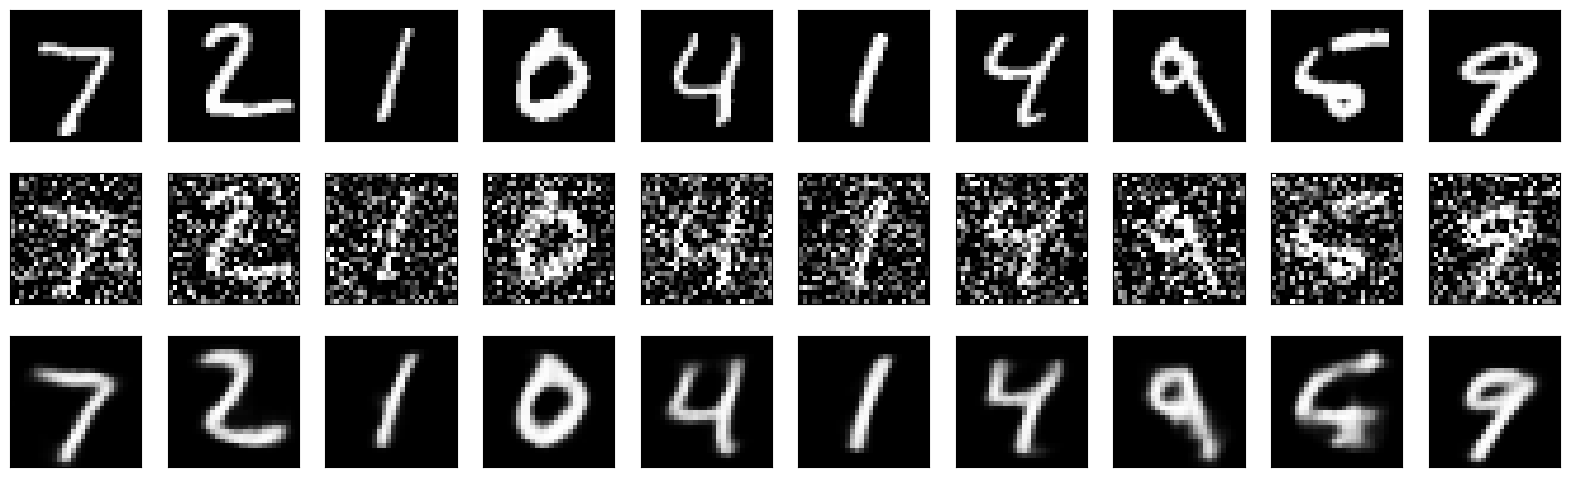

In [15]:
import matplotlib.pyplot as plt

## Predict the denoised images
denoised_images = diffusion_model.predict(x_test_noisy)

## Visualize the results
n = 10   ## Number of digits to display
plt.figure(figsize=(20,6))

for i in range(n):
    ## Display original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ## Display noisy
    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ## Display denoised
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(denoised_images[i].reshape(28,28),cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

#### Step 6: Fine-tune the diffusion model

Fine-tune the diffusion model by unfreezing some layers and retraining the model to improve its performance.


**1. Freeze the model layers:**
- Freeze all the layers of the encoder.

**2. Check the Status:**
- Checking the trainable status of each layer.

**3. Unfreeze the model layers:**
- Unfreeze the last few layers of the model to allow them to be retrained.

**4. Compile and train the model:**
- Recompile the model.
- Train the model again for an additional 10 epochs.


In [16]:
## Freeze all the layers

for layer in diffusion_model.layers:
    layer.trainable = False




In [17]:
## Check trainable status of each layer

for i, layer in enumerate(diffusion_model.layers):
    print(f'Layer {i}: {layer.name}  - Trainable : {layer.trainable}')

Layer 0: input_layer_4  - Trainable : False
Layer 1: conv2d_11  - Trainable : False
Layer 2: conv2d_12  - Trainable : False
Layer 3: flatten_4  - Trainable : False
Layer 4: dense_7  - Trainable : False
Layer 5: dense_8  - Trainable : False
Layer 6: reshape_3  - Trainable : False
Layer 7: conv2d_transpose_6  - Trainable : False
Layer 8: conv2d_transpose_7  - Trainable : False
Layer 9: conv2d_13  - Trainable : False


In [18]:
## Unfreeze the top layers of the model.
for layer in diffusion_model.layers[-6:]:
    layer.trainable = True

## Compile tje model again
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

## Train the model again
diffusion_model.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 261s 552ms/step - loss: 0.1147
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 253s 540ms/step - loss: 0.1112
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 254s 541ms/step - loss: 0.1080
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 270s 556ms/step - loss: 0.1066
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 262s 558ms/step - loss: 0.1054
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 261s 557ms/step - loss: 0.1039
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 263s 558ms/step - loss: 0.1027
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 255s 545ms/step - loss: 0.1010
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 264s 549ms/step - loss: 0.1003
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 260s 555ms/step - loss: 0.0993
